# OP26 — Phase 2: Exploratory Data Analysis
Reads the Phase-1 outputs and produces deck-ready figures, the **empirical peak-window definition**, EDA summary tables, and a data-driven findings doc. Logic lives in `eda.py`; run top-to-bottom to regenerate everything in `figures/` and the `eda_*` files in `outputs/`.

**Two band concepts are kept distinct:** *operational* bands (per zone-hour: util ≥ 0.80 surge, < 0.30 discount — the brief's triggers) vs *temporal* peak windows (which hours are systematically busy — defined here by tertiles of mean hourly utilization).

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings('ignore')
sys.path.insert(0, str(Path.cwd().parent))
import pandas as pd
from IPython.display import Image, display
import config as C, eda as E
panel, zf, info, acn = E.load()
print('panel', panel.shape, '| zones', len(zf), '| acn', len(acn))

panel (177840, 42) | zones 247 | acn 14947


## Temporal profiling + empirical peak windows
Occupancy peaks **overnight** (vehicles sit plugged in) and troughs **midday**; weekday and weekend are near-identical, so the cycle is time-of-day, not day-of-week. The midday trough is the prime discount window; network-wide surge is essentially absent (it lives in a zone tail).

,hour,mean_util,band
0,0,0.3319,peak
1,1,0.3343,peak
2,2,0.3284,peak
3,3,0.3260,peak
4,4,0.3247,peak
5,5,0.3267,peak
6,6,0.3313,peak
7,7,0.3028,shoulder
8,8,0.2611,shoulder
9,9,0.2502,offpeak


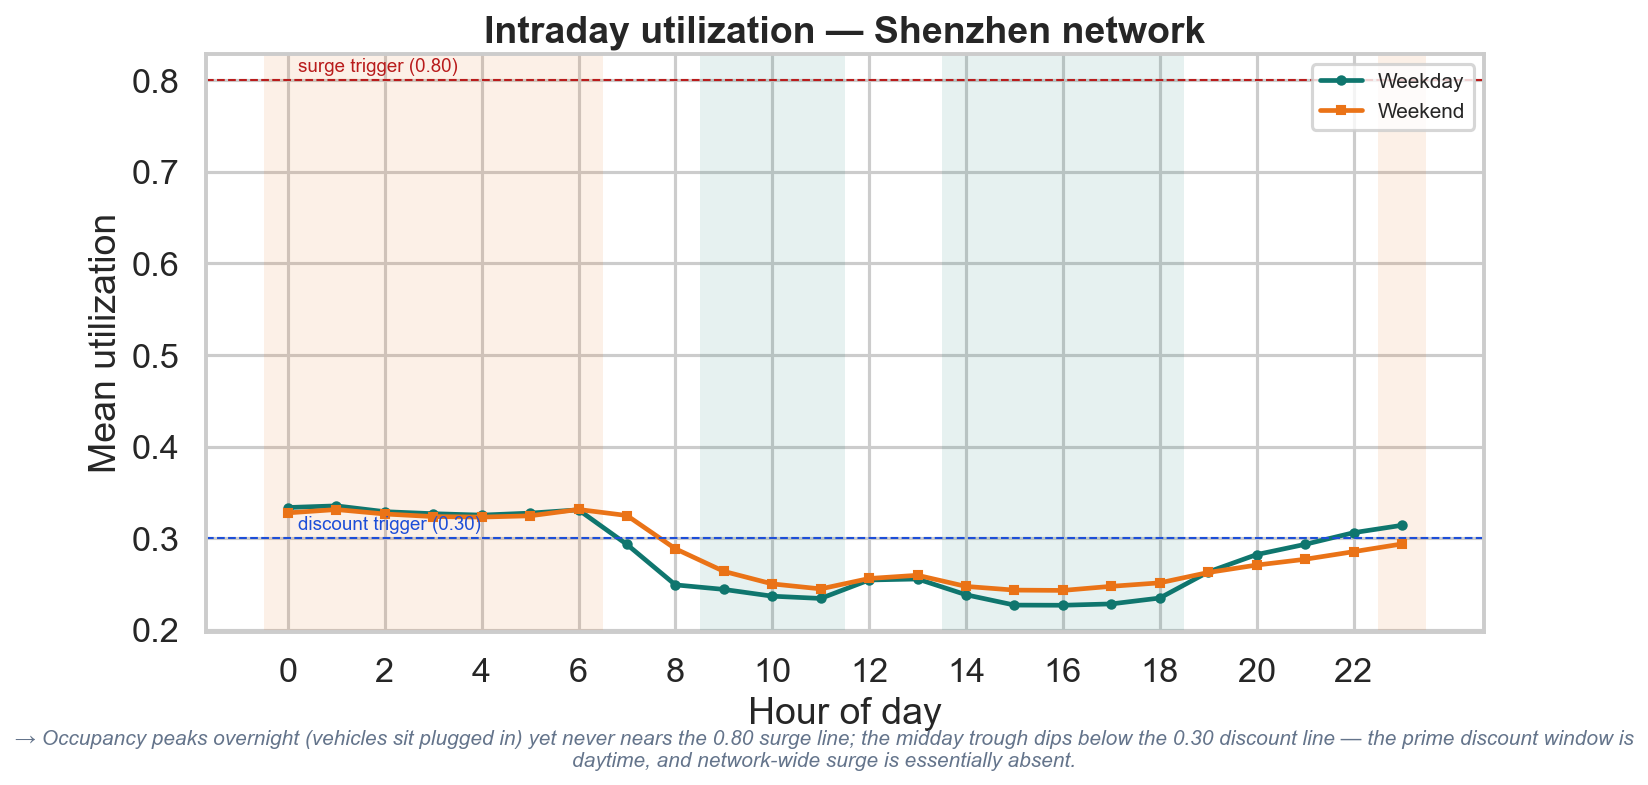

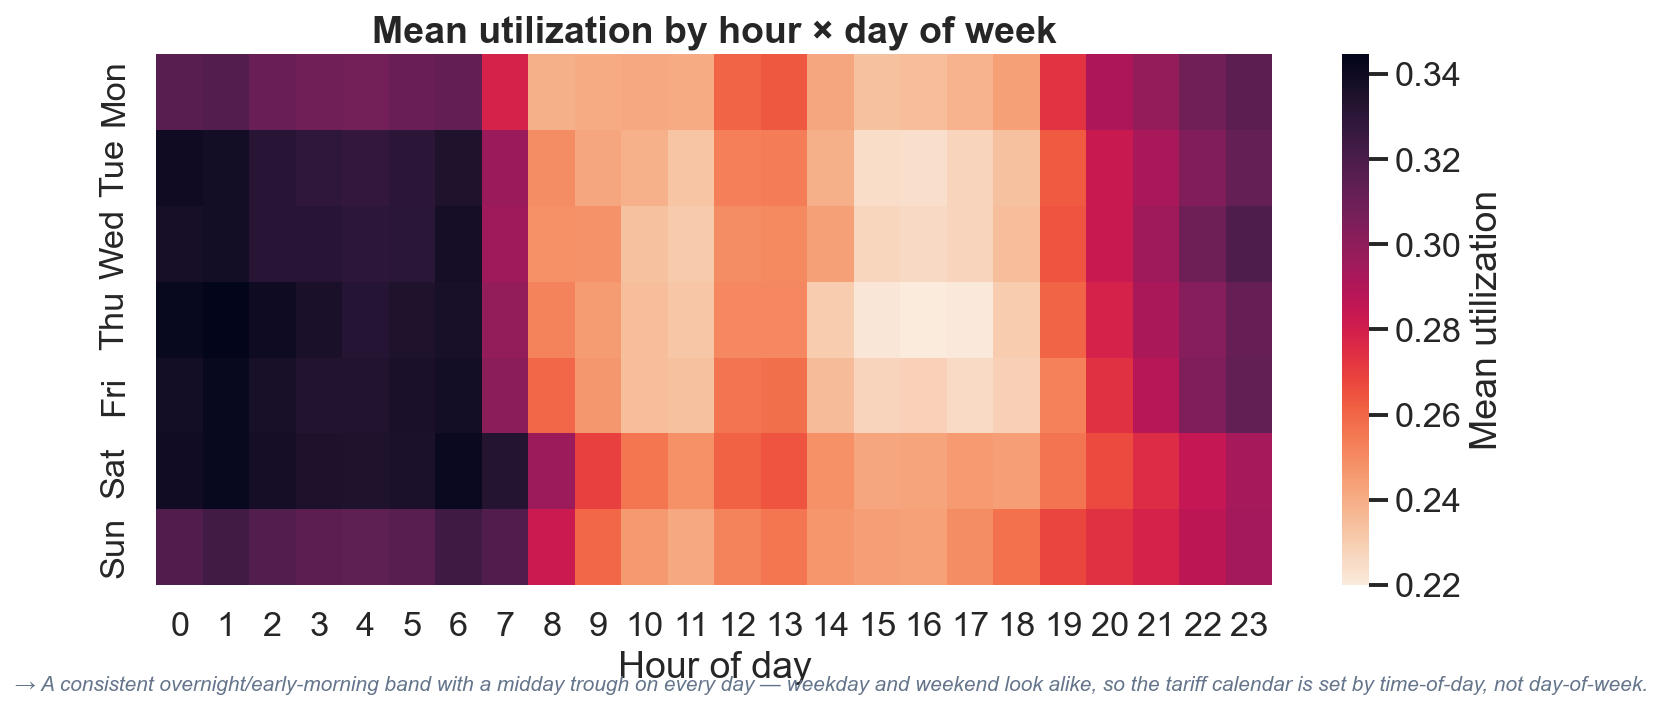

In [2]:
overall, wd, we = E.temporal(panel)
E.fig_intraday(overall, wd, we); E.fig_heatmap(panel)
display(pd.read_csv(C.OUTPUT_DIR/'peak_windows.csv').query("scope=='overall'")[['hour','mean_util','band']])
display(Image(C.FIG_DIR/'fig01_intraday_utilization.png'))
display(Image(C.FIG_DIR/'fig02_util_heatmap_hour_dow.png'))

## Volatility by band
The quiet midday (off-peak) window is modestly but consistently the least predictable → daytime discounts should be scheduled/sustained, not reactive.

,mean,std,cv
tband,,,
offpeak,0.238493,0.147473,0.618356
shoulder,0.275806,0.166264,0.602829
peak,0.326429,0.194923,0.597136


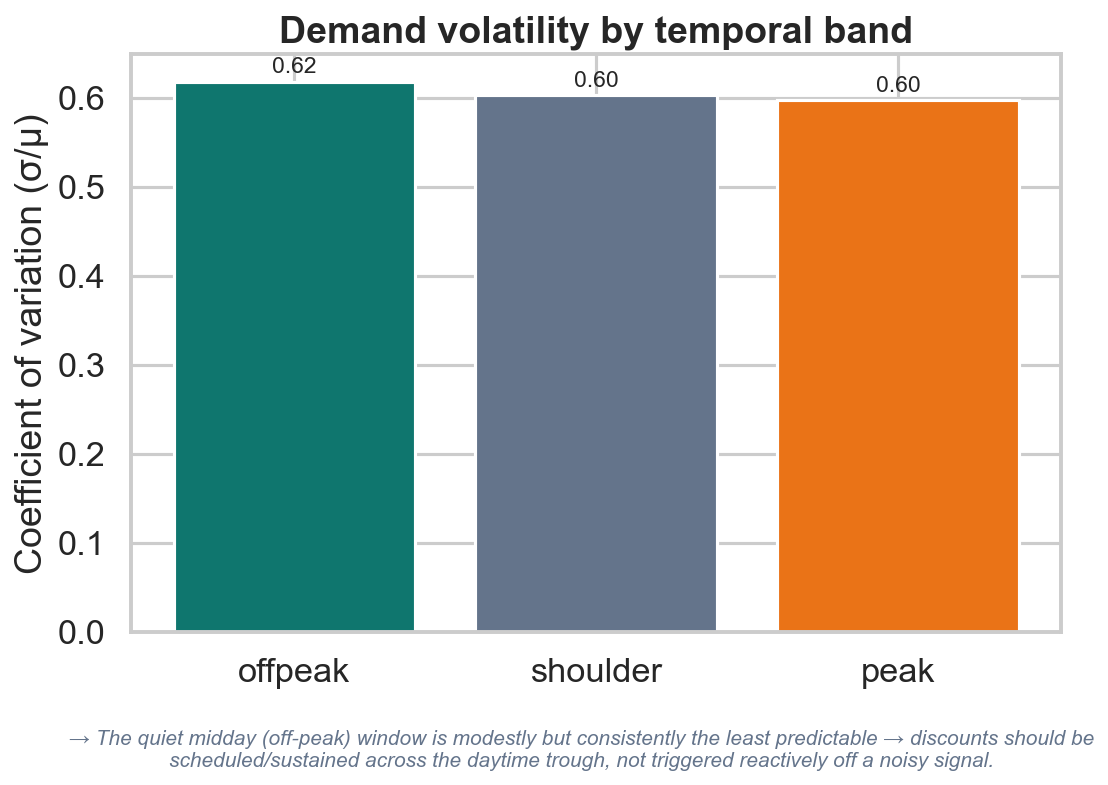

In [3]:
vol = E.fig_volatility(panel, overall)
display(vol)
display(Image(C.FIG_DIR/'fig03_volatility_by_band.png'))

## Spatial profile — and the CBD surprise
Congestion is concentrated in the **top ~10% of zones (~all surge incidence)**, and those are **not** the CBD (CBD util is actually lower). → surge must be targeted by *observed* utilization, not the CBD label.

,n,util_mean,pct_peak,pct_offpeak,price_mean,revenue_total
grp,,,,,,
CBD,62,0.2426,0.0012,0.6987,1.0160,141181.4155
non-CBD,185,0.2929,0.0122,0.5823,0.9393,298722.4373


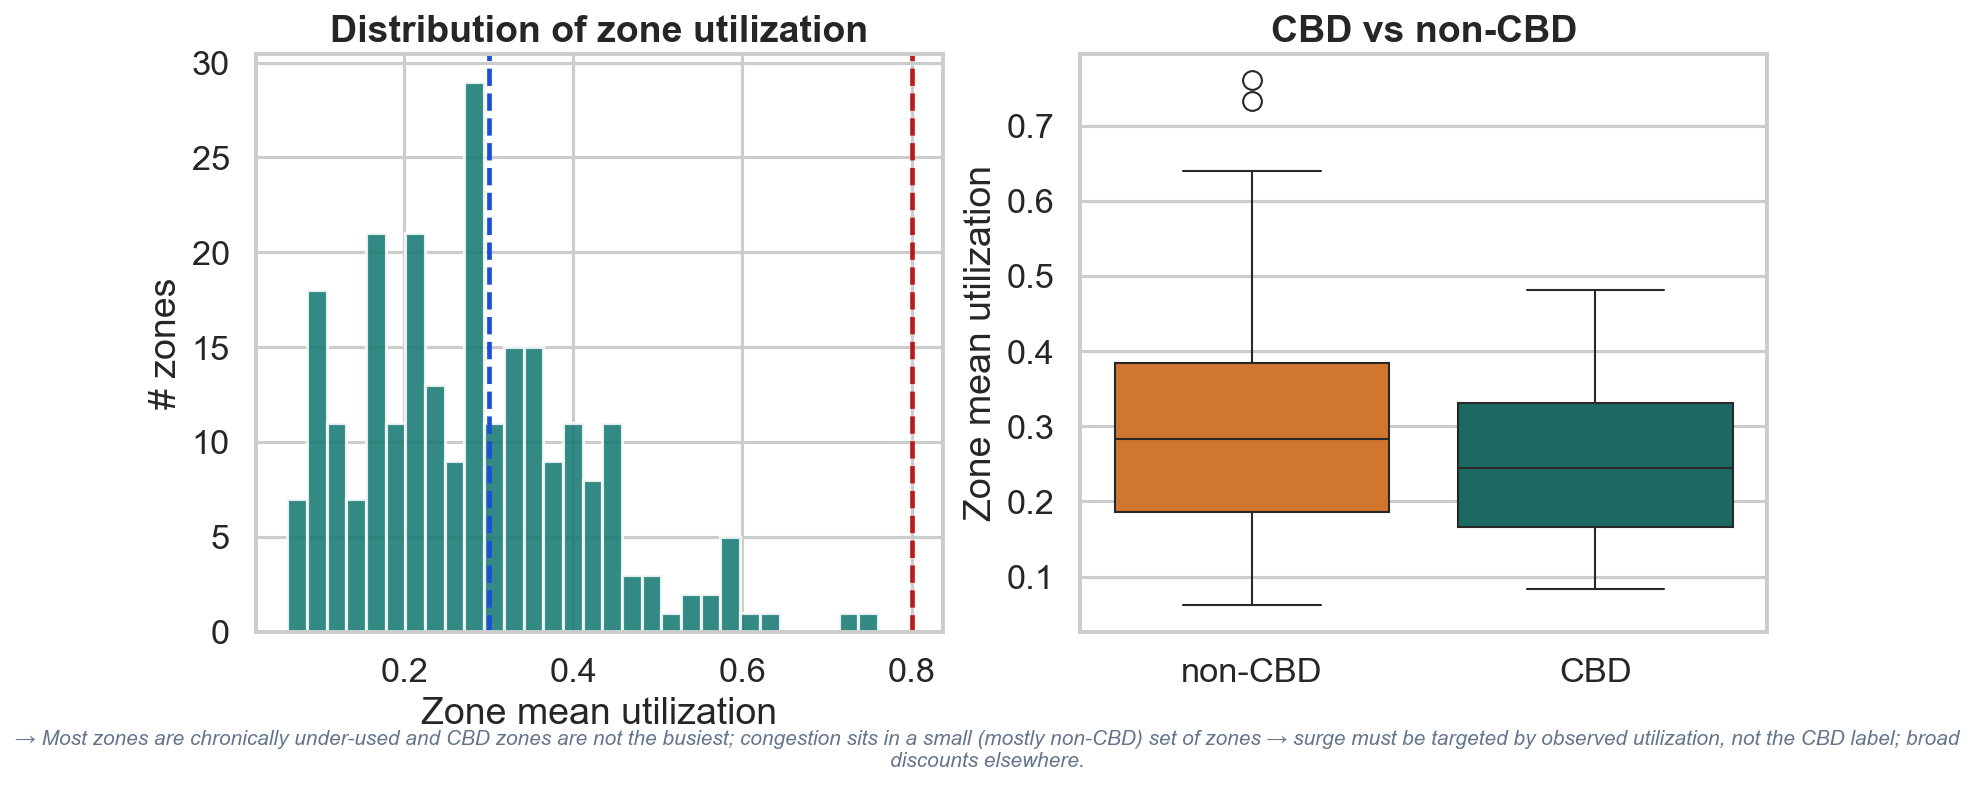

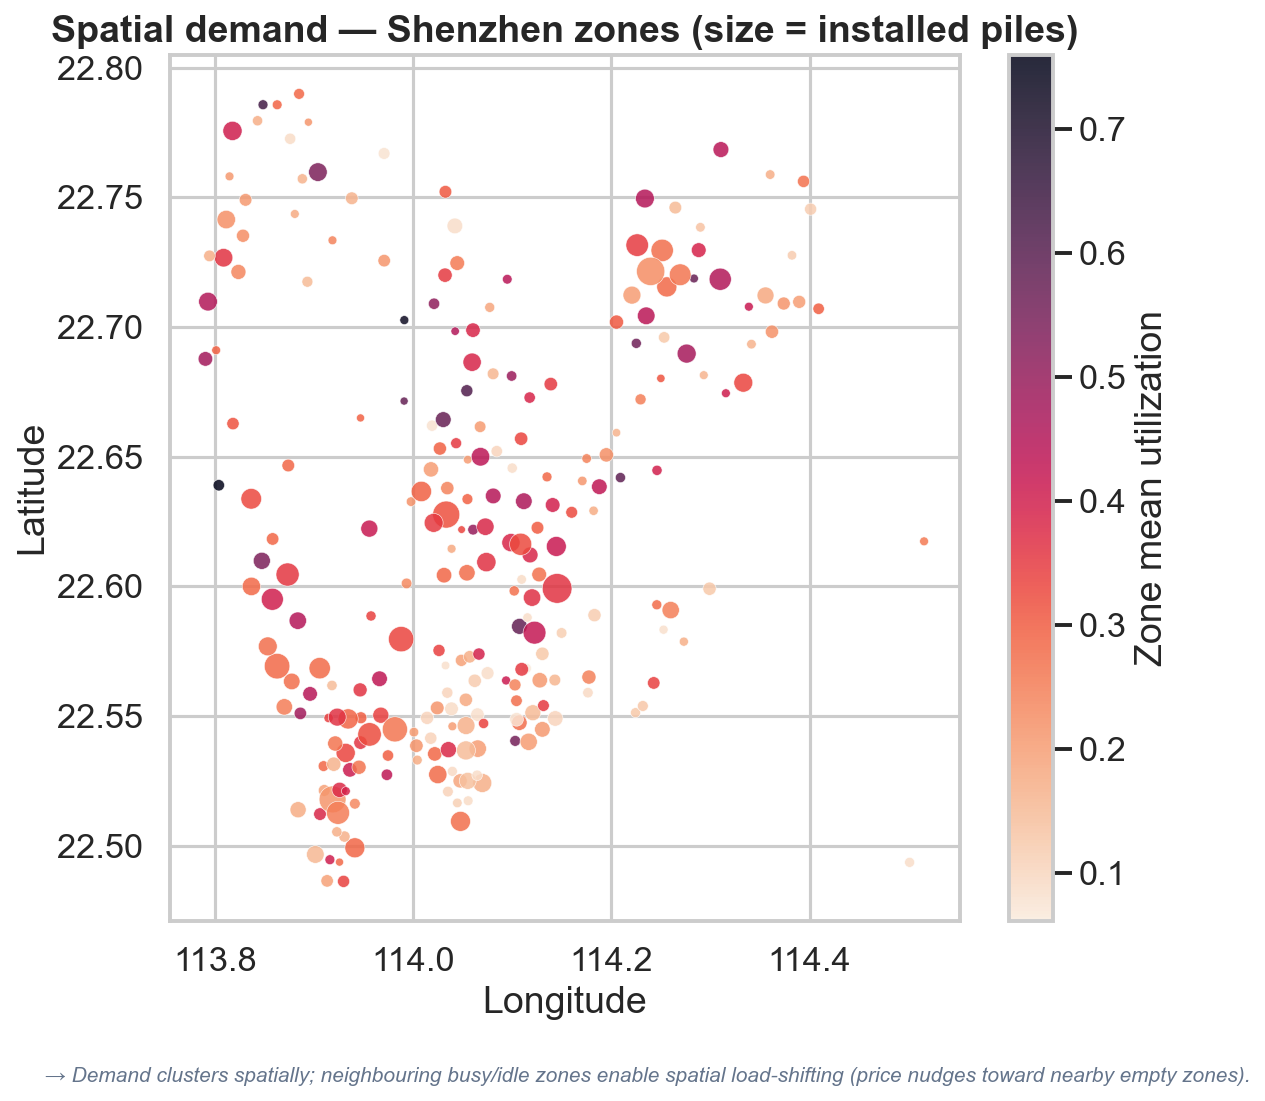

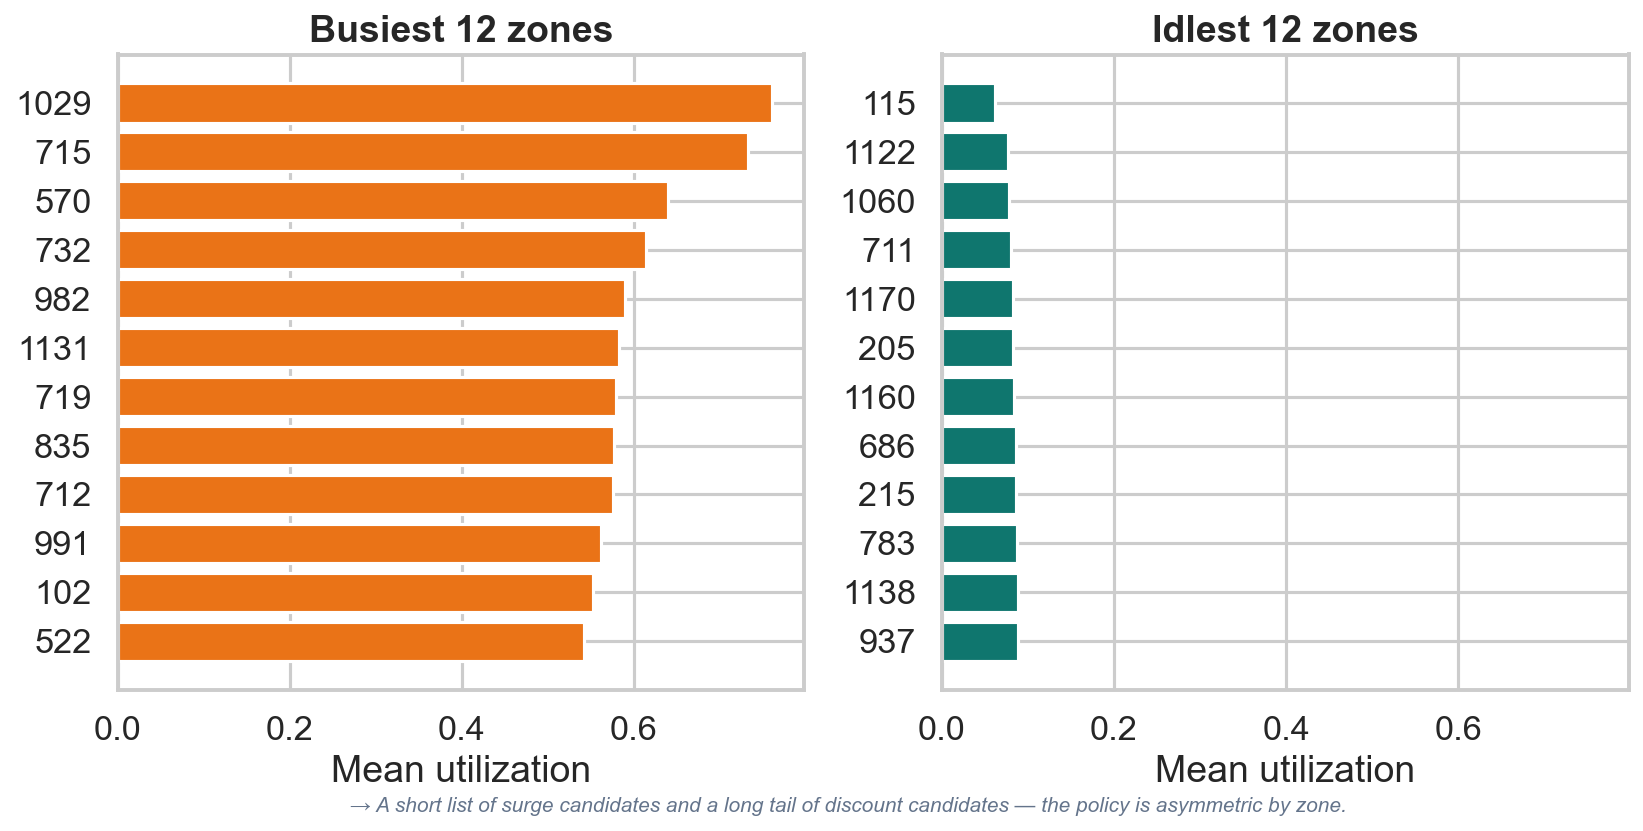

In [4]:
cbd = E.fig_zone_dist_cbd(zf); E.fig_map(zf, info); E.fig_top_bottom(zf)
display(cbd)
for f in ['fig04_zone_utilization_distribution','fig05_spatial_map','fig06_top_bottom_zones']:
    display(Image(C.FIG_DIR/f'{f}.png'))

## Price vs demand — preliminary (associational) elasticity
Across the 108 price-varying zones, higher tariffs associate with lower demand. Reported as an **associational** signal (per the brief's no-causal-claims rule); re-estimated rigorously in Phase 4.

preliminary elasticity ~ -0.32 over 108 price-varying zones


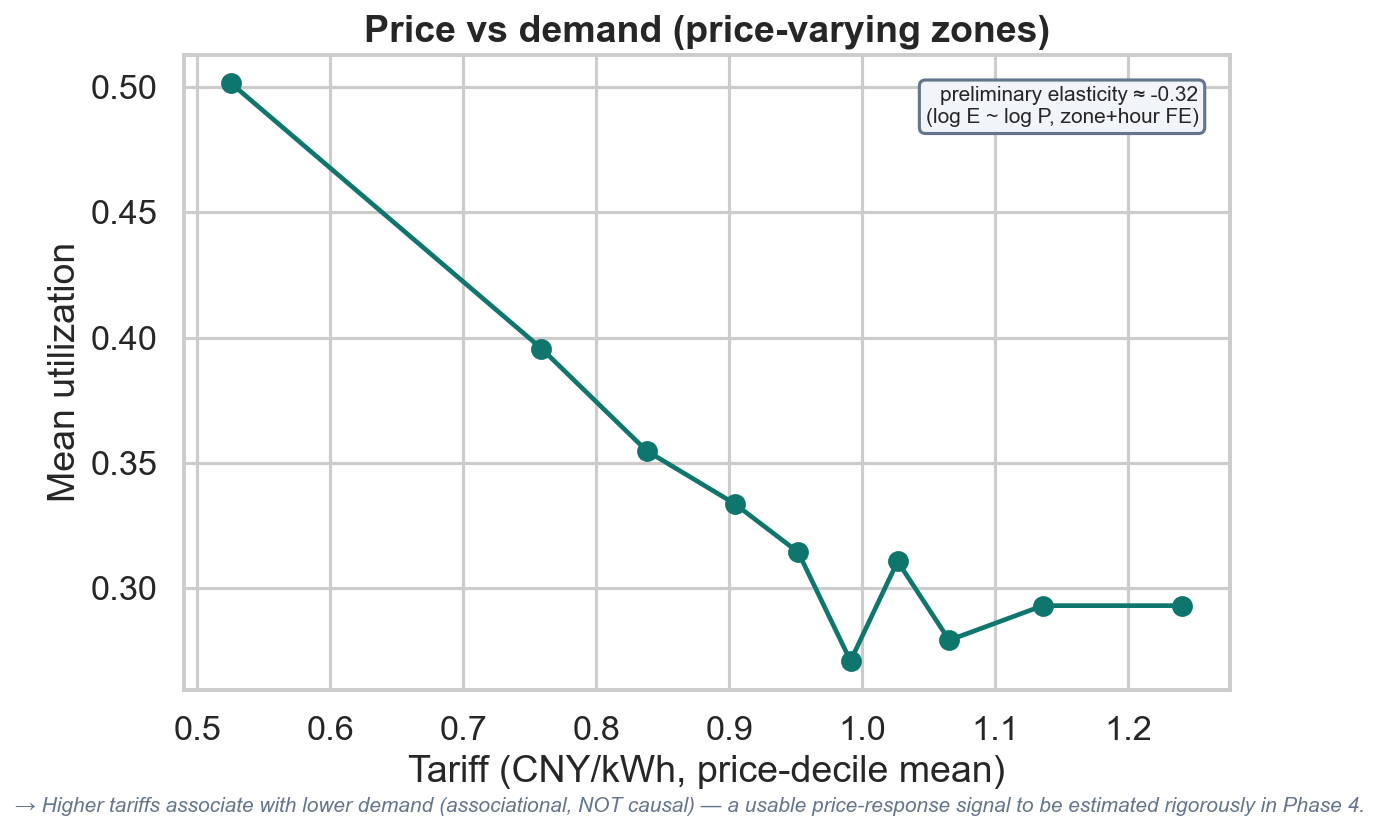

In [5]:
elasticity, n_pv = E.fig_price_demand(panel)
print(f'preliminary elasticity ~ {elasticity:+.2f} over {n_pv} price-varying zones')
display(Image(C.FIG_DIR/'fig07_price_vs_demand.png'))

## ACN behaviour
Long post-charge idle (connector blocking), a strong morning arrival peak, and mostly anonymous sessions (only ~15% identified). → idle/occupancy fees + a morning surge can free capacity.

,value
acn_median_dwell_hr,4.735556
acn_median_charging_hr,2.242639
acn_median_idle_hr,0.725278
acn_median_idle_ratio,0.181807
acn_pct_idle_gt_1h,0.463504
acn_pct_identified,0.148859
acn_user_gini,0.583926
acn_top10pct_user_session_share,0.399551
acn_median_laxity_hr,1.348889


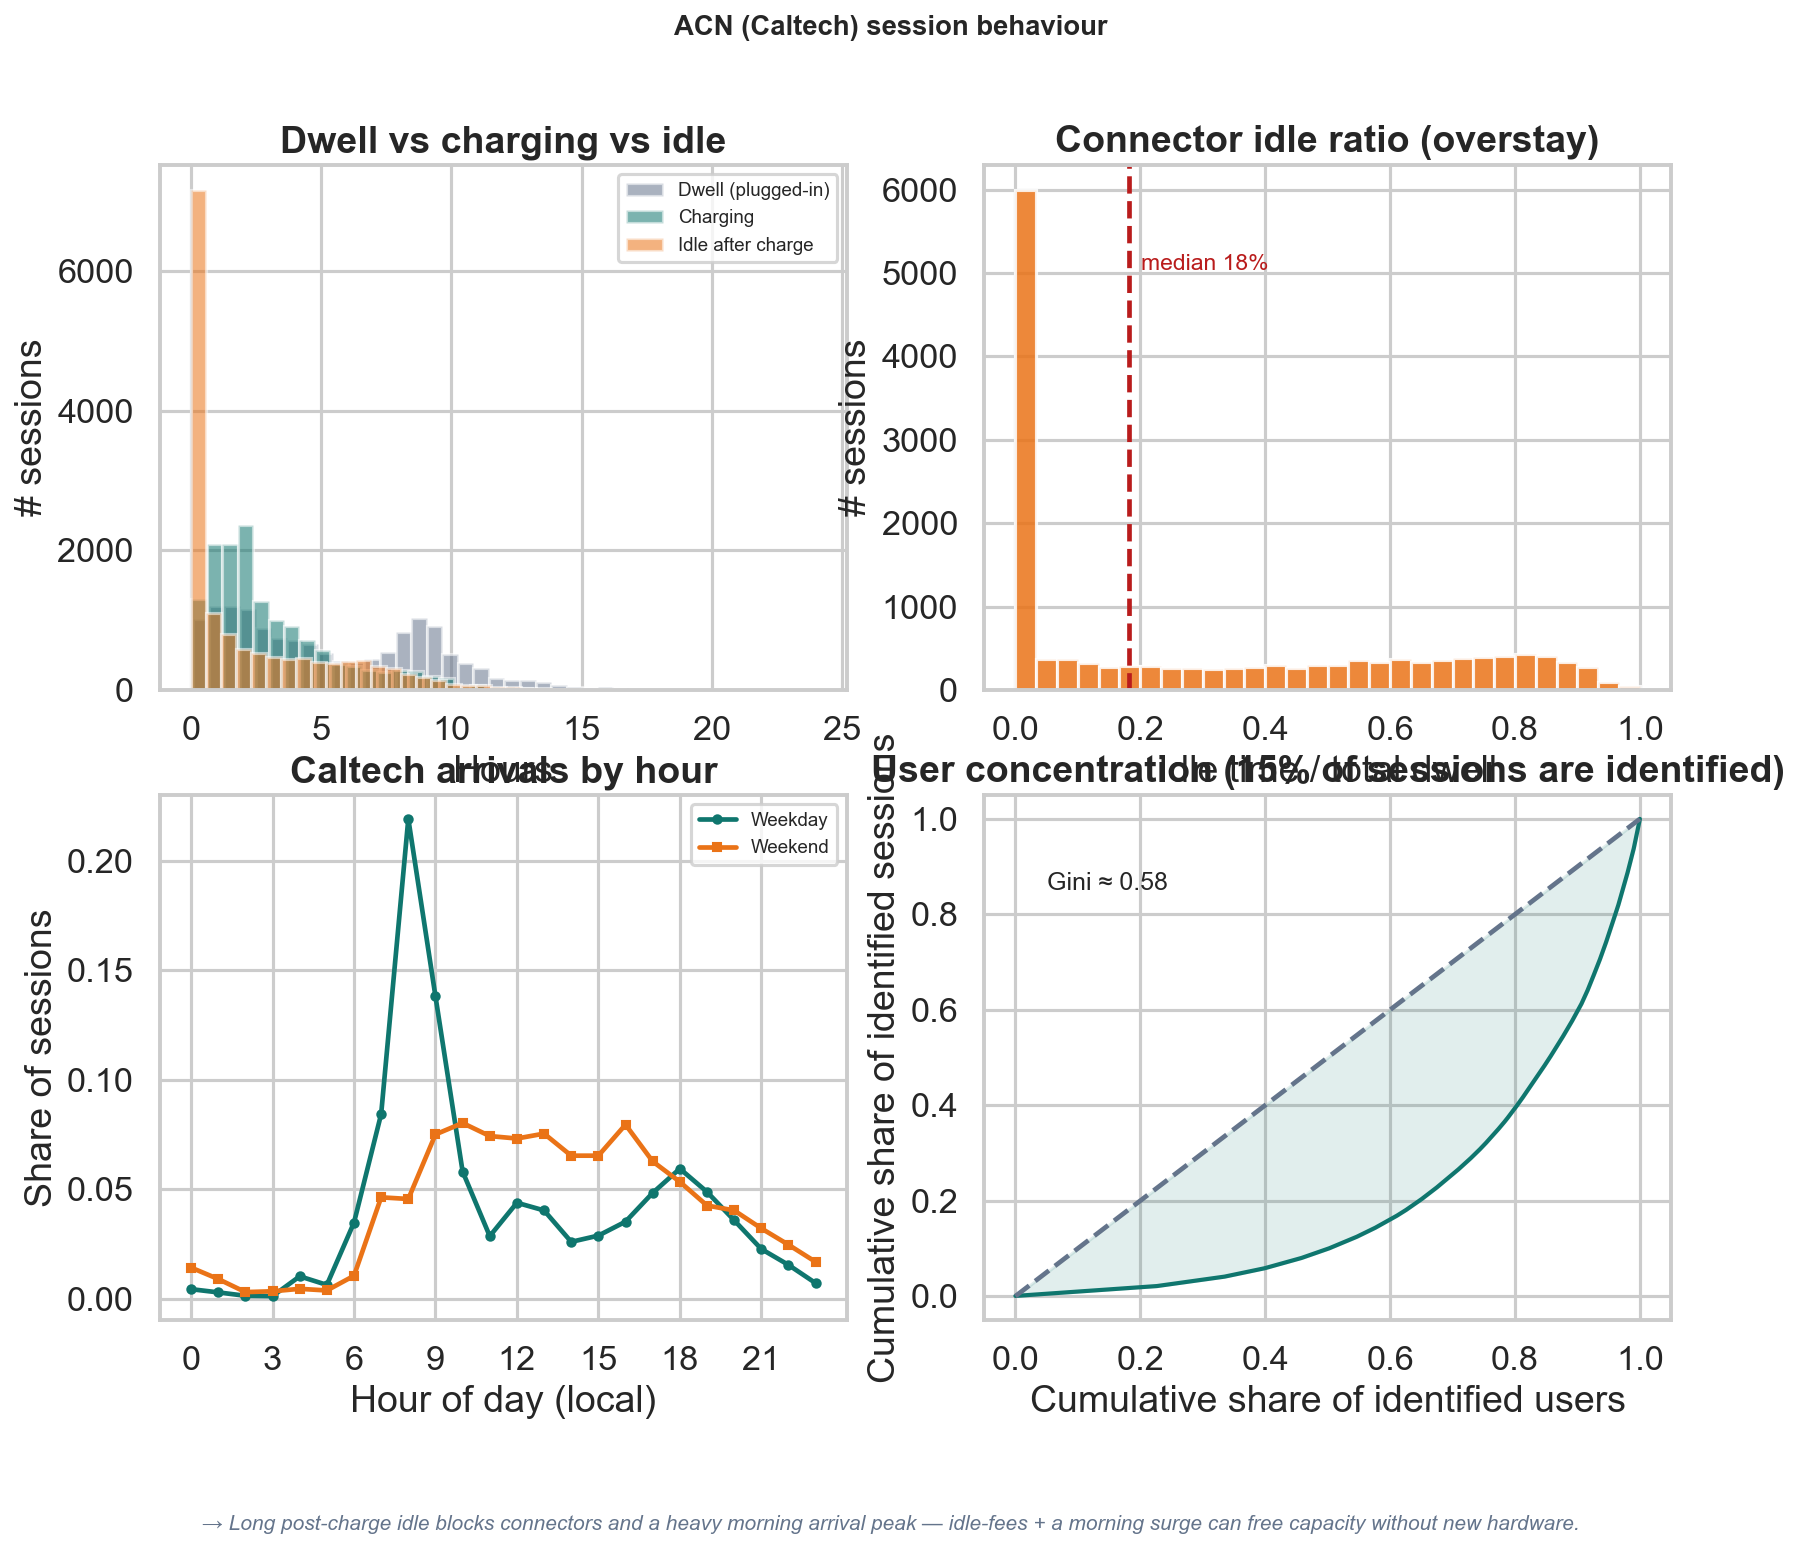

In [6]:
acn_sum = E.fig_acn(acn)
display(pd.DataFrame([acn_sum]).T.rename(columns={0:'value'}))
display(Image(C.FIG_DIR/'fig08_acn_behaviour.png'))

## Write the findings doc

In [7]:
E.write_findings(panel, overall, vol, cbd, elasticity, n_pv, acn_sum)
print((C.OUTPUT_DIR/'eda_findings.md').read_text()[:1500])

# Phase 2 — EDA Findings (each tied to a pricing implication)

All figures are in `figures/`. Two band concepts are kept distinct:
**operational bands** (per zone-hour: util ≥ 80% surge, < 30% discount — the brief's triggers)
and **temporal peak windows** (which *hours* are systematically busy — defined below).

## 1. The network is chronically under-used (fig01, fig04)
Only **0.9%** of zone-hours exceed the 80% surge trigger, while **61.1%** fall
below the 30% discount trigger. → **Implication:** the dominant revenue/efficiency lever is
**off-peak discounting to fill empty capacity**, with surge as a targeted, secondary tool.

## 2. Demand is driven by time-of-day, not day-of-week (fig01, fig02)
Occupancy peaks **overnight / early-morning** (00:00, 01:00, 02:00, 03:00, 04:00, 05:00, 06:00, 23:00) — vehicles sit plugged in — and
troughs **midday** (09:00, 10:00, 11:00, 14:00, 15:00, 16:00, 17:00, 18:00). Weekend and weekday means are nearly identical
(0.28 vs 0.28), so the cycle is int

---
**Phase 2 complete.** `peak_windows.csv` + the EDA findings feed Phase 3 (demand agent) and Phase 4 (tariff agent).